# Feature Engineering: Telco Customer Churn

**Purpose:** Build and validate all engineered features used in modelling. This notebook walks through the reasoning behind each feature decision, validates distributions, and confirms the processed dataset is model-ready.

**Notebook Structure:**
1. Setup — Run ETL Pipeline
2. RFM Proxy Features
3. Engagement Score
4. Contract & Payment Risk
5. Tenure Band & Customer Segments
6. Feature Validation & Correlation with Churn
7. Final Feature Set Summary

---

## 1. Setup 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import sys
import os

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

from src.utils import PROCESSED_DIR
from src.etl.ingest import run_ingestion
from src.etl.clean import run_cleaning
from src.etl.features import (
    add_rfm_features, add_engagement_score,
    add_risk_features, add_tenure_band, add_risk_segment
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('Libraries loaded.')

Libraries loaded.


In [3]:
# Run ingestion and cleaning (idempotent — safe to re-run)
print('Running ETL pipeline...')
run_ingestion()
df_clean = run_cleaning()
print(f'\nClean dataset shape: {df_clean.shape}')
df_clean.head(3)

2026-03-12 14:31:29 | INFO | etl.ingest | Loaded raw data: 7043 rows, 21 columns
2026-03-12 14:31:29 | INFO | utils.validate_schema | Schema validation passed.
2026-03-12 14:31:29 | INFO | etl.ingest | Churn rate in raw data: 26.54%
2026-03-12 14:31:29 | INFO | etl.ingest | Null values found: 0


Running ETL pipeline...


2026-03-12 14:31:29 | INFO | etl.ingest | Ingested data saved to: c:\Users\Takunda\Documents\development\Data POC\telco-churn-intelligence\data\processed\01_ingested.csv
2026-03-12 14:31:29 | INFO | etl.clean | Loaded ingested data: (7043, 21)
2026-03-12 14:31:29 | INFO | etl.clean | TotalCharges nulls: 11 (imputing with MonthlyCharges)
2026-03-12 14:31:29 | INFO | etl.clean | Encoded binary: Partner
2026-03-12 14:31:29 | INFO | etl.clean | Encoded binary: Dependents
2026-03-12 14:31:29 | INFO | etl.clean | Encoded binary: PhoneService
2026-03-12 14:31:29 | INFO | etl.clean | Encoded binary: PaperlessBilling
2026-03-12 14:31:29 | INFO | etl.clean | Encoded binary: Churn
2026-03-12 14:31:29 | INFO | etl.clean | Encoded service col: OnlineSecurity
2026-03-12 14:31:29 | INFO | etl.clean | Encoded service col: OnlineBackup
2026-03-12 14:31:29 | INFO | etl.clean | Encoded service col: DeviceProtection
2026-03-12 14:31:29 | INFO | etl.clean | Encoded service col: TechSupport
2026-03-12 14:31


Clean dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1



## 2. RFM Proxy Features

**RFM (Recency, Frequency, Monetary)** is a classic marketing framework for segmenting customers. We adapt it using the available Telco features.

| RFM Dimension | Business Meaning | Telco Proxy |
|---|---|---|
| Recency | How recently did the customer engage? | Inverted tenure |
| Frequency | How often do they interact? | Services subscribed count |
| Monetary | How much value do they generate? | TotalCharges |

2026-03-12 14:31:41 | INFO | etl.features | Added RFM proxy features.


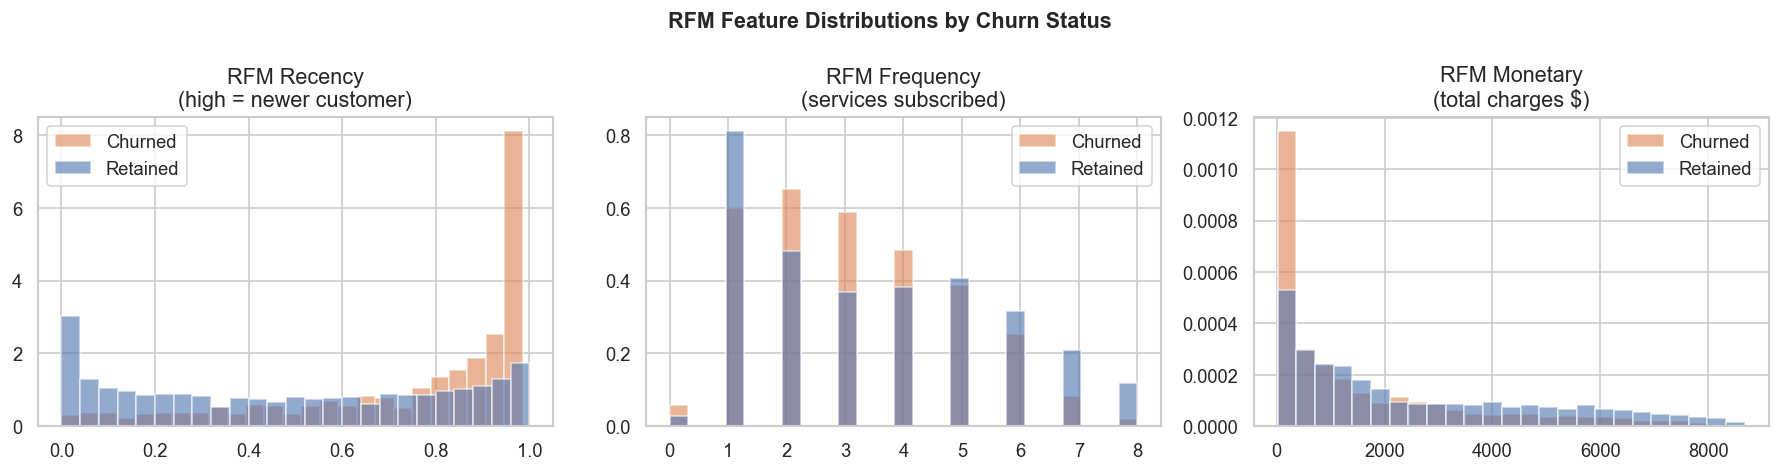

In [4]:
df = add_rfm_features(df_clean.copy())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm_cols = ['rfm_recency', 'rfm_frequency', 'rfm_monetary']
titles = ['RFM Recency\n(high = newer customer)', 
          'RFM Frequency\n(services subscribed)', 
          'RFM Monetary\n(total charges $)']

churn_map = {1: 'Churned', 0: 'Retained'}

for ax, col, title in zip(axes, rfm_cols, titles):
    for churn_val, label, color in [(1, 'Churned', '#DD8452'), (0, 'Retained', '#4C72B0')]:
        subset = df[df['Churn'] == churn_val][col]
        ax.hist(subset, bins=25, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(title)
    ax.legend()

plt.suptitle('RFM Feature Distributions by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# RFM means by churn status
df.groupby('Churn')[rfm_cols].mean().round(3)

,rfm_recency,rfm_frequency,rfm_monetary
Churn,,,
0,0.478,3.446,2549.999
1,0.750,3.132,1531.796


**Validation:** Churned customers should show higher recency (newer), lower frequency (fewer services), and lower monetary (less total spend). Confirm in the table above.

## 3. Engagement Score

The **engagement_score** captures how deeply a customer is embedded in the product ecosystem. A customer using 0 of 6 optional services has little switching cost — they're easy to lose.

2026-03-12 14:32:07 | INFO | etl.features | Added engagement score features.


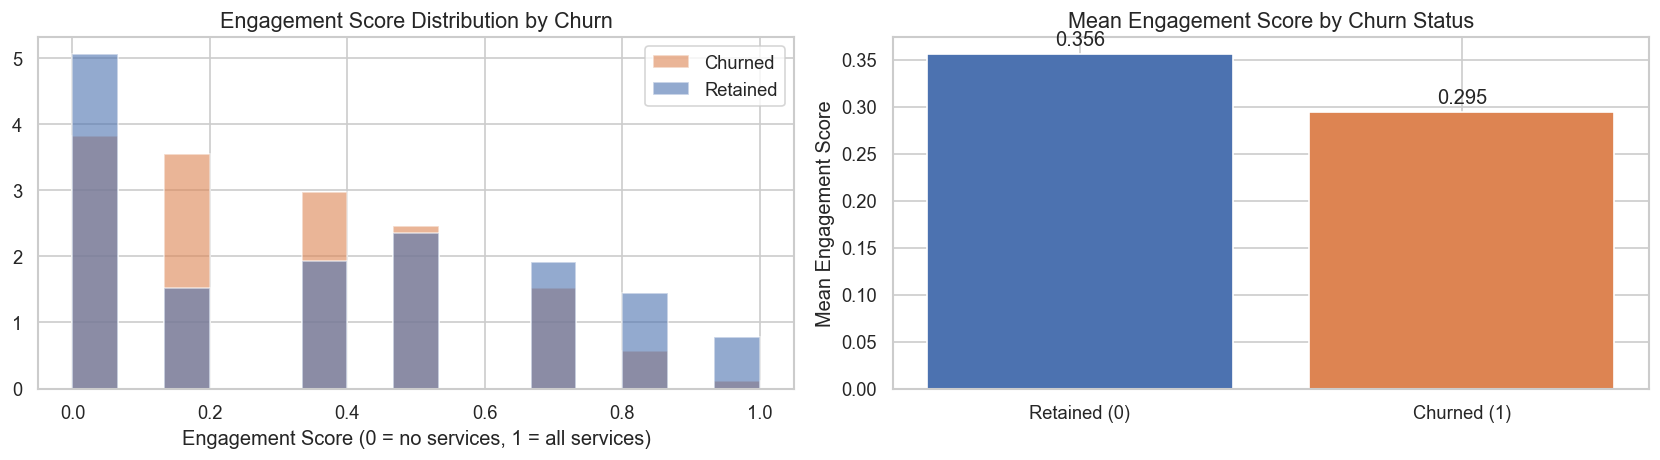

In [6]:
df = add_engagement_score(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution by churn
for churn_val, label, color in [(1, 'Churned', '#DD8452'), (0, 'Retained', '#4C72B0')]:
    subset = df[df['Churn'] == churn_val]['engagement_score']
    axes[0].hist(subset, bins=15, alpha=0.6, label=label, color=color, density=True)
axes[0].set_title('Engagement Score Distribution by Churn')
axes[0].set_xlabel('Engagement Score (0 = no services, 1 = all services)')
axes[0].legend()

# Average engagement by churn
avg_eng = df.groupby('Churn')['engagement_score'].mean()
bars = axes[1].bar(['Retained (0)', 'Churned (1)'], avg_eng.values, 
                   color=['#4C72B0', '#DD8452'])
axes[1].set_title('Mean Engagement Score by Churn Status')
axes[1].set_ylabel('Mean Engagement Score')
for bar, val in zip(bars, avg_eng.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 4. Contract & Payment Risk

We convert contract type and payment method into **ordinal risk scores** based on known churn patterns observed in EDA. This gives tree models a useful ordinal signal.

2026-03-12 14:32:19 | INFO | etl.features | Added contract and payment risk features.
2026-03-12 14:32:19 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-12 14:32:19 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-12 14:32:19 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-12 14:32:19 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, c

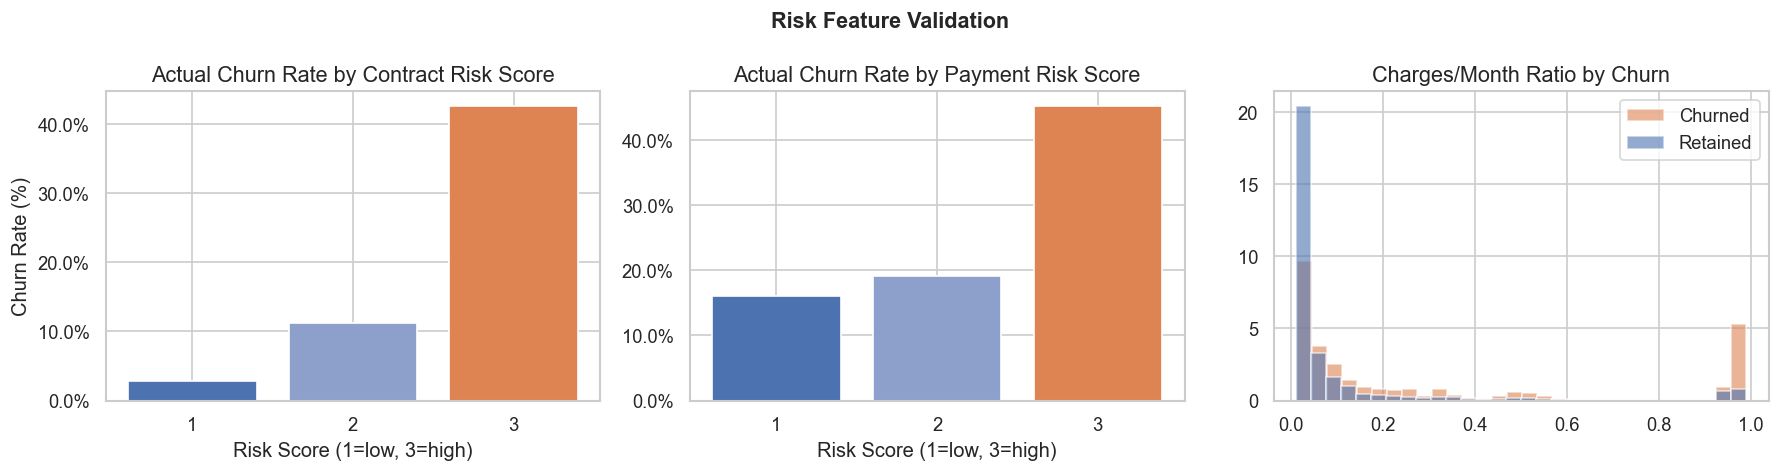

In [7]:
df = add_risk_features(df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Contract risk vs actual churn rate
cr = df.groupby('contract_risk')['Churn'].mean() * 100
axes[0].bar(cr.index.astype(str), cr.values, color=['#4C72B0', '#8DA0CB', '#DD8452'])
axes[0].set_title('Actual Churn Rate by Contract Risk Score')
axes[0].set_xlabel('Risk Score (1=low, 3=high)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Payment risk vs actual churn rate
pr = df.groupby('payment_risk')['Churn'].mean() * 100
axes[1].bar(pr.index.astype(str), pr.values, color=['#4C72B0', '#8DA0CB', '#DD8452'])
axes[1].set_title('Actual Churn Rate by Payment Risk Score')
axes[1].set_xlabel('Risk Score (1=low, 3=high)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# Charges per month ratio
for churn_val, label, color in [(1, 'Churned', '#DD8452'), (0, 'Retained', '#4C72B0')]:
    subset = df[df['Churn'] == churn_val]['charges_per_month_ratio']
    axes[2].hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
axes[2].set_title('Charges/Month Ratio by Churn')
axes[2].legend()

plt.suptitle('Risk Feature Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Validation:** If our risk scoring is well-calibrated, churn rate should increase monotonically with risk score (1 → 2 → 3).

## 5. Tenure Band & Customer Segments

2026-03-12 14:33:13 | INFO | etl.features | Added tenure band.
2026-03-12 14:33:13 | INFO | etl.features | Risk segments:
risk_segment
Medium Risk    5443
High Risk       884
Low Risk        716
Name: count, dtype: int64


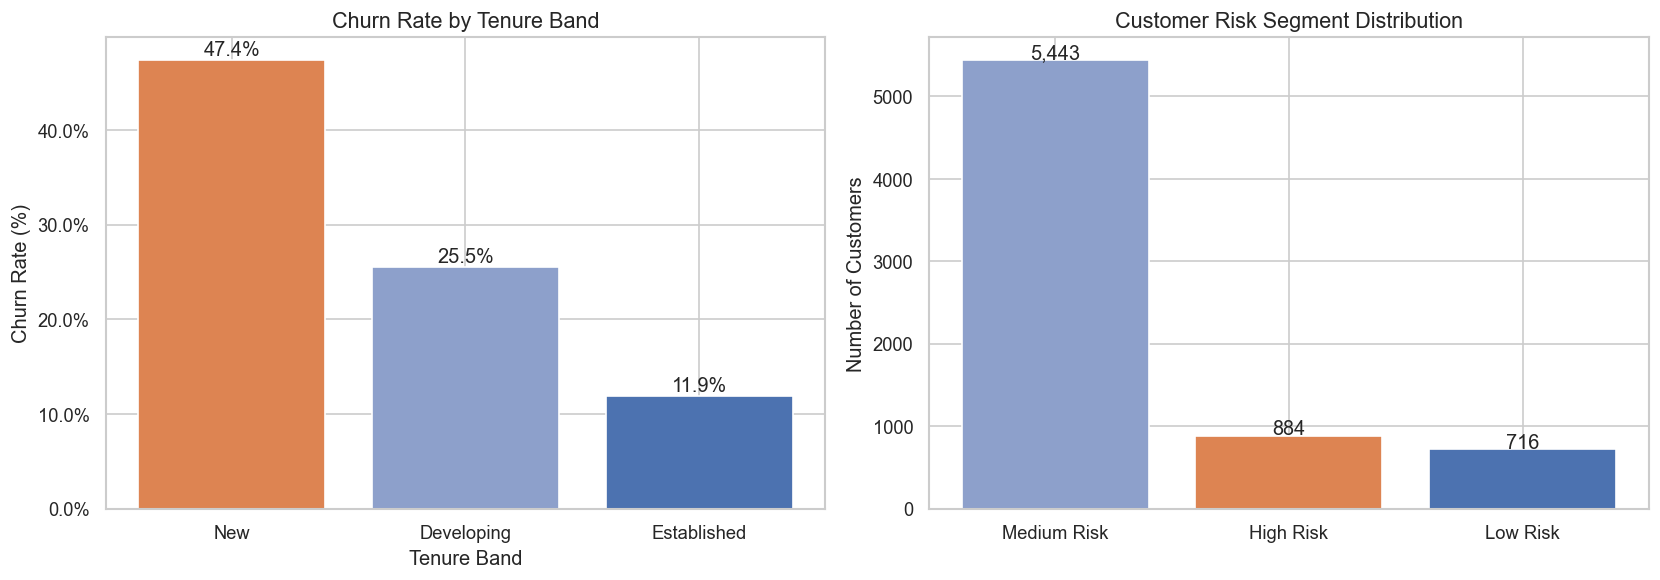

In [8]:
df = add_tenure_band(df)
df = add_risk_segment(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by tenure band
tb = df.groupby('tenure_band', observed=True)['Churn'].mean() * 100
axes[0].bar(tb.index, tb.values, color=['#DD8452', '#8DA0CB', '#4C72B0'])
axes[0].set_title('Churn Rate by Tenure Band')
axes[0].set_xlabel('Tenure Band')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, val in enumerate(tb.values):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center')

# Risk segment distribution
rs = df['risk_segment'].value_counts()
colors = {'High Risk': '#DD8452', 'Medium Risk': '#8DA0CB', 'Low Risk': '#4C72B0'}
bar_colors = [colors[x] for x in rs.index]
axes[1].bar(rs.index, rs.values, color=bar_colors)
axes[1].set_title('Customer Risk Segment Distribution')
axes[1].set_ylabel('Number of Customers')
for i, val in enumerate(rs.values):
    axes[1].text(i, val + 20, f'{val:,}', ha='center')

plt.tight_layout()
plt.show()

## 6. Feature Validation: Correlation with Churn

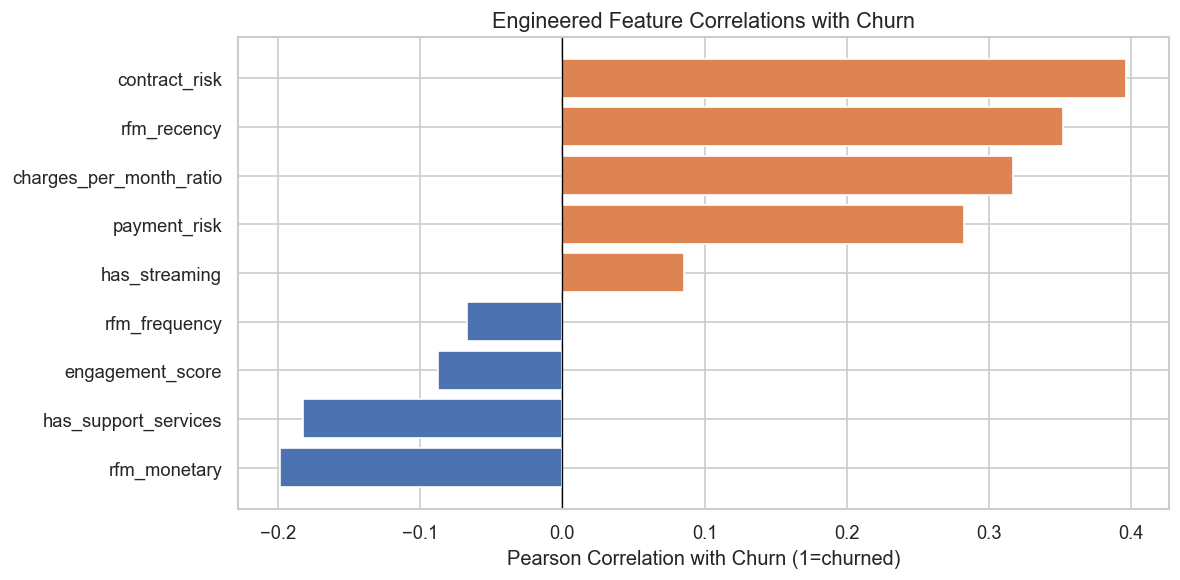

In [9]:
# All engineered numeric features
engineered_features = [
    'rfm_recency', 'rfm_frequency', 'rfm_monetary',
    'engagement_score', 'has_streaming', 'has_support_services',
    'contract_risk', 'payment_risk', 'charges_per_month_ratio',
]

corr_with_churn = df[engineered_features + ['Churn']].corr()['Churn'].drop('Churn').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_with_churn.values]
ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Engineered Feature Correlations with Churn', fontsize=13)
ax.set_xlabel('Pearson Correlation with Churn (1=churned)')
plt.tight_layout()
plt.show()

## 7. Final Feature Set Summary

In [10]:
# Save the full feature dataset
from src.etl.features import run_feature_engineering
df_final = run_feature_engineering()

print(f'Final dataset: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns')
print(f'Original columns: 21')
print(f'Engineered features added: {df_final.shape[1] - 21}')
print()
print('New columns:')
original_cols = set(df_clean.columns)
new_cols = [c for c in df_final.columns if c not in original_cols]
for col in new_cols:
    print(f'  + {col}')

2026-03-12 14:33:46 | INFO | etl.features | Loaded cleaned data: (7043, 21)
2026-03-12 14:33:46 | INFO | etl.features | Added RFM proxy features.
2026-03-12 14:33:46 | INFO | etl.features | Added engagement score features.
2026-03-12 14:33:47 | INFO | etl.features | Added contract and payment risk features.
2026-03-12 14:33:47 | INFO | etl.features | Added tenure band.
2026-03-12 14:33:47 | INFO | etl.features | Risk segments:
risk_segment
Medium Risk    5443
High Risk       884
Low Risk        716
Name: count, dtype: int64
2026-03-12 14:33:47 | INFO | etl.features | Feature data saved to: c:\Users\Takunda\Documents\development\Data POC\telco-churn-intelligence\data\processed\03_features.csv
2026-03-12 14:33:47 | INFO | etl.features | Final shape: (7043, 32) | 11 features added


Final dataset: 7,043 rows × 32 columns
Original columns: 21
Engineered features added: 11

New columns:
  + rfm_recency
  + rfm_frequency
  + rfm_monetary
  + engagement_score
  + has_streaming
  + has_support_services
  + contract_risk
  + payment_risk
  + charges_per_month_ratio
  + tenure_band
  + risk_segment


In [11]:
# Preview final dataset
df_final[['customerID', 'tenure', 'MonthlyCharges', 'Churn',
           'rfm_recency', 'rfm_frequency', 'rfm_monetary',
           'engagement_score', 'contract_risk', 'risk_segment', 'tenure_band']].head(10)

,customerID,tenure,MonthlyCharges,Churn,rfm_recency,rfm_frequency,rfm_monetary,engagement_score,contract_risk,risk_segment,tenure_band
0,7590-VHVEG,1,29.85,0,0.986111,1,29.85,0.166667,3,High Risk,New
1,5575-GNVDE,34,56.95,0,0.527778,3,1889.50,0.333333,2,Medium Risk,Developing
2,3668-QPYBK,2,53.85,1,0.972222,3,108.15,0.333333,3,Medium Risk,New
3,7795-CFOCW,45,42.30,0,0.375000,3,1840.75,0.500000,2,Medium Risk,Established
4,9237-HQITU,2,70.70,1,0.972222,1,151.65,0.000000,3,High Risk,New
5,9305-CDSKC,8,99.65,1,0.888889,5,820.50,0.500000,3,Medium Risk,New
6,1452-KIOVK,22,89.10,0,0.694444,4,1949.40,0.333333,3,Medium Risk,Developing
7,6713-OKOMC,10,29.75,0,0.861111,1,301.90,0.166667,3,Medium Risk,New
8,7892-POOKP,28,104.80,1,0.611111,6,3046.05,0.666667,3,Medium Risk,Developing
9,6388-TABGU,62,56.15,0,0.138889,3,3487.95,0.333333,2,Medium Risk,Established



## Author

- **Name:** Takunda Madondo